<a href="https://colab.research.google.com/github/hanbiphyun/ESSA_YB/blob/main/ESAA_OB_week3_1_%EC%B6%94%EC%B2%9C%EC%8B%9C%EC%8A%A4%ED%85%9C_%ED%95%84%EC%82%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<파이썬 머신러닝 완벽가이드>
p.584~601

##9장 추천시스템
- 개요 : 전자상거래 업체에 추천시스템을 도입함으로써 매출을 크게 증가시킴 (아마존, 이베이 등) -> 고도화에 큰 비용과 투자 진행
- 온라인 스토어에서 큰 영향 있음

• 사용자가 어떤 상품을 구매했는가?

• 사용자가 어떤 상품을 둘러보거나 장바구니에 넣었는가?

• 사용자가 평가한 영화 평점은? 제품 평가는?

• 사용자가 스스로 작성한 자신의 취향은?

• 사용자가 무엇을 클릭했는가?

**추천시스템의 유형**
1. 콘텐츠 기반 필터링
: 사용자가 선호하는 아이템과 비슷한 아이템 추천


2. 협업 필터링

: 사용자-아이템 평점 행렬 데이터에 의지함
  - 행 : 개별 사용자, 열 : 개별 아이템 -> pivot_table()로 형태 맞춰주기도 함
- 최근접 이웃 협업 필터링 = 메모리 협업 필터링
  - 사용자가 아이템에 매긴 평점 정보나 상품구매 이력과 같은 사용자 행동양식에 기반하여 추천
  - 예측 평가 방식
  1. 사용자 기반 - 당신과 비슷한 고객의 구매 방식 이용
    - Top-N 선정하여 유사도 높은 타 사용자의 데이터로 예측
  2. 아이템 기반 - 당신이 구매한 아이템을 선택한 다른 고객의 구매 방식 이용

  -> 사용자기반 < 아이템 기반 정확도
- 잠재요인 협업 필터링 (요즘 온라인 스토어에서 사용)

: 대규모 다차원 행렬을 SVD같은 차원감소기법으로 분해하는 과정에서 잠재 요인 추출
  - 사용자가 예측하지 않은 아이템에 대한 평점 도출
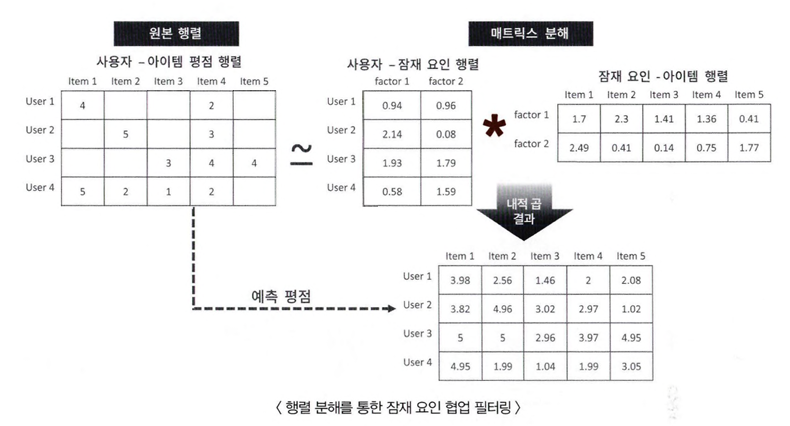

- R= P*Q.T
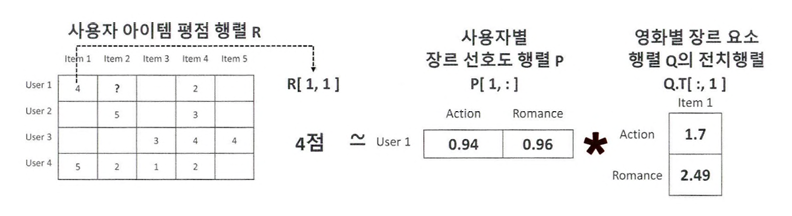

**행렬 분해의 이해**
: 다차원 매트릭스-> 저차원 매트릭스로 분해
- SVD, NMF
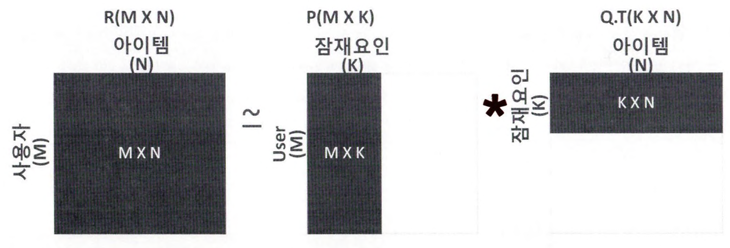
- M은총사용자수
- N은 총아이템수
- K는 잠재요인의 차원수
- R은 M X N 차원의 사용자-아이템 평점 행렬
- P 는 사용자와 잠재 요인과의 관계 값을 가자는 M X K 차원의 사용자-잠재 요인 행렬
- Q 는 아이템과 잠재 요인과의 관계 값을 가지는 N X K 차원의 아이템一잠재 요인 행렬
- Q.T는 Q 매트릭스의 행과 열 값을 교환한 전치 행렬
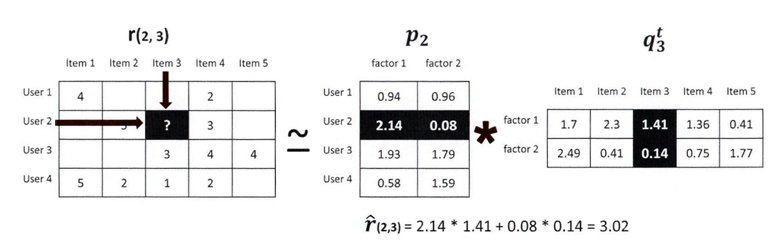

- R행렬을 P와 Q행렬로 분해 방법 : SVD -> 널값없는 행렬만 적용가능 => SGD, ALS(Alternating Least Squares) 방식이용

**확률적 경사 하강법을 이용한 행렬분해**
: P와 Q행렬로 계산된 예측 R행렬 값이 실제 값과 오차가 최소가 되도록 비용함수 최적화하여 P,Q 유추하는것
- 비용함수식 (오류 최소화, L2 규제 고려)
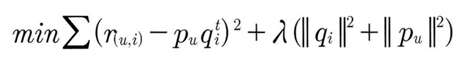

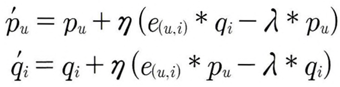
- r(u,i) : 실제 R행렬에 위치한 값
- e(u,i) : 실제값-예측행렬값 차이오류
- n : SGD 학습률
- lambda : L2규제 계수

In [5]:
import numpy as np

# 원본 행렬 R 생성, 분해 행렬 P와 Q 초기화, 잠재 요인 차원 K는 3으로 설정
R= np.array([[4, np.nan,np.nan, 2, np.nan],
             [np.nan, 5, np.nan, 3,1],
             [np.nan, np.nan, 3, 4, 4],
             [5,2,1,2,np.nan]])
num_users, num_items= R.shape

#잠재 요인 차원 설정
K=3

#P와 Q행렬의 크기를 지정하고 정규분포를 가진 임의의 값으로 입력합니다.
np.random.seed(1)
P= np.random.normal(scale=1./K, size=(num_users, K))
Q= np.random.normal(scale=1./K, size=(num_items, K))

실제 R행렬과 에측행렬의 오차 구하는 get_rmse()함수 만들기
- 널이 아닌 행렬값의 위치인덱스 추출하여 이용

In [6]:
from sklearn.metrics import mean_squared_error

def get_rmse(R,P,Q, non_zeros):
    error=0
    # 두개의 분해된 행렬 P와 Q.T의 내적으로 예측 R행렬 생성
    full_pred_matrix= np.dot(P, Q.T)

    # 실제 R행렬에서 널이 아닌 값의 위치 인덱스 추출해 실제 R행렬과 예측행렬의 RMSE추출
    x_non_zero_ind= [non_zero[0] for non_zero in non_zeros]
    y_non_zero_ind= [non_zero[1] for non_zero in non_zeros]
    R_non_zeros= R[x_non_zero_ind, y_non_zero_ind]
    full_pred_matrix_non_zeros= full_pred_matrix[x_non_zero_ind, y_non_zero_ind]
    mse= mean_squared_error(R_non_zeros, full_pred_matrix_non_zeros)
    rmse= np.sqrt(mse)

    return rmse

- SGD기반으로 행렬 분해 수행

In [7]:
# R>0 인 행위치, 열위치, 값을 non_zeros 리스트에 저장
non_zeros= [(i,j,R[i,j]) for i in range(num_users) for j in range(num_items) if R[i,j]>0]

steps=1000
learning_rate=0.01
r_lambda= 0.01

# SGD기법으로 P와 Q 매트릭스를 계속 업데이트
for step in range(steps):
    for i, j, r in non_zeros:
        # 실제값과 예측값의 차이인 오류 값 구함
        eij = r- np.dot(P[i,:], Q[j,:].T)
        #Regularization을 반영한 SGD업데이트 공식적용
        P[i,:]= P[i,:]+learning_rate*(eij*Q[j,:]- r_lambda*P[i,:])
        Q[j,:]= Q[j,:]+learning_rate*(eij*P[i,:]- r_lambda*Q[j,:])
        rmse= get_rmse(R,P,Q, non_zeros)
        if (step %50)==0:
            print('### iteration step:', step,'rmse:', rmse)

### iteration step: 0 rmse: 3.261355059488935
### iteration step: 0 rmse: 3.26040057174686
### iteration step: 0 rmse: 3.253984404542389
### iteration step: 0 rmse: 3.2521583839863624
### iteration step: 0 rmse: 3.252335303789125
### iteration step: 0 rmse: 3.251072196430487
### iteration step: 0 rmse: 3.2492449982564864
### iteration step: 0 rmse: 3.247416477570409
### iteration step: 0 rmse: 3.241926055455223
### iteration step: 0 rmse: 3.2400454107613084
### iteration step: 0 rmse: 3.240166740749792
### iteration step: 0 rmse: 3.2388050277987723
### iteration step: 50 rmse: 0.5003190892212748
### iteration step: 50 rmse: 0.5001616291326989
### iteration step: 50 rmse: 0.49899601202578087
### iteration step: 50 rmse: 0.4988483450145831
### iteration step: 50 rmse: 0.49895189256631756
### iteration step: 50 rmse: 0.49833236830090993
### iteration step: 50 rmse: 0.4984148489378701
### iteration step: 50 rmse: 0.49792599580240876
### iteration step: 50 rmse: 0.4900605568692785
### itera

In [8]:
pred_matrix= np.dot(P,Q.T)
print('예측 행렬:\n', np.round(pred_matrix,3))

예측 행렬:
 [[3.991 0.897 1.306 2.002 1.663]
 [6.696 4.978 0.979 2.981 1.003]
 [6.677 0.391 2.987 3.977 3.986]
 [4.968 2.005 1.006 2.017 1.14 ]]
